 Practice-4-mohammad hasan mosaferi

تمرین 4_ محمد حسن مسافری 

شماره دانشجویی:4042013200

In [15]:
# Practice-4-mohammad hasan mosaferi

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1)تابع اصلی
def process_image(image_path):
    
    #  خواندن تصویر   
    img = cv2.imread(image_path)
    
    # اگر تصویر خوانده نشد، پیغام خطا بده
    if img is None:
        print("خطا: تصویر پیدا نشد!")
        return
    
    # تبدیل تصویر از BGR به RGB (چون matplotlib با RGB کار می‌کند)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # تبدیل تصویر به خاکستری برای محاسبه هیستوگرام
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # محاسبه هیستوگرام تصویر خاکستری
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
    
    # ایجاد subplot با 3 ردیف و 2 ستون
    fig, axs = plt.subplots(3, 2, figsize=(12, 15))
    
    # ========== ردیف اول ==========
    # موقعیت (1,1) - تصویر اصلی
    axs[0, 0].imshow(img_rgb)
    axs[0, 0].set_title("تصویر اصلی")
    axs[0, 0].axis('off')
    
    # موقعیت (1,2) - هیستوگرام تصویر اصلی
    axs[0, 1].plot(hist, color='black')
    axs[0, 1].set_title("هیستوگرام تصویر اصلی")
    axs[0, 1].set_xlim([0, 256])
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)
    axs[0, 1].set_xlabel("شدت روشنایی")
    axs[0, 1].set_ylabel("تعداد پیکسل‌ها")
    
    # ========== ردیف دوم: تبدیل سفید به سیاه و سیاه به سفید ==========
    # کپی از تصویر اصلی برای تغییر
    img_white_black = img_rgb.copy()
    
    # پیکسل‌های سفید خالص (255,255,255) را به سیاه (0,0,0) تبدیل کن
    # و پیکسل‌های سیاه خالص (0,0,0) را به سفید (255,255,255) تبدیل کن
    for i in range(img_white_black.shape[0]):
        for j in range(img_white_black.shape[1]):
            # اگر پیکسل سفید بود
            if (img_white_black[i, j] == [255, 255, 255]).all():
                img_white_black[i, j] = [0, 0, 0]
            # اگر پیکسل سیاه بود
            elif (img_white_black[i, j] == [0, 0, 0]).all():
                img_white_black[i, j] = [255, 255, 255]
    
    # تبدیل تصویر تغییر یافته به خاکستری برای هیستوگرام
    img_white_black_gray = cv2.cvtColor(img_white_black, cv2.COLOR_RGB2GRAY)
    hist_white_black = cv2.calcHist([img_white_black_gray], [0], None, [256], [0, 256])
    
    # موقعیت (2,1) - تصویر بعد از تبدیل سفید↔سیاه
    axs[1, 0].imshow(img_white_black)
    axs[1, 0].set_title("تصویر: سفید به سیاه و سیاه به سفید")
    axs[1, 0].axis('off')
    
    # موقعیت (2,2) - هیستوگرام تصویر تبدیل شده
    axs[1, 1].plot(hist_white_black, color='black')
    axs[1, 1].set_title("هیستوگرام تصویر سفید↔سیاه شده")
    axs[1, 1].set_xlim([0, 256])
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)
    axs[1, 1].set_xlabel("شدت روشنایی")
    axs[1, 1].set_ylabel("تعداد پیکسل‌ها")
    
    # ========== ردیف سوم: معکوس کردن سمت چپ و راست هیستوگرام ==========
    # معکوس کردن هیستوگرام نسبت به محور تقارن در شدت 128
    hist_flipped = np.zeros_like(hist)
    for i in range(256):
        # شدت i به شدت (255 - i) منتقل می‌شود
        hist_flipped[i] = hist[255 - i]
    
    img_inverted = 255 - img_gray   # معکوس ساده شدت روشنایی
    
    # موقعیت (3,1) - تصویر تغییر یافته
    axs[2, 0].imshow(img_inverted, cmap='gray')
    axs[2, 0].set_title("تصویر با هیستوگرام معکوس شده")
    axs[2, 0].axis('off')
    
    # موقعیت (3,2) - هیستوگرام معکوس شده
    # هیستوگرام تصویر معکوس شده را محاسبه می‌کنیم تا ببینیم معکوس شده
    hist_inverted = cv2.calcHist([img_inverted], [0], None, [256], [0, 256])
    
    axs[2, 1].plot(hist_inverted, color='black')
    axs[2, 1].set_title("هیستوگرام معکوس شده (آینه‌ای نسبت به 128)")
    axs[2, 1].set_xlim([0, 256])
    axs[2, 1].grid(True, linestyle='--', alpha=0.7)
    axs[2, 1].set_xlabel("شدت روشنایی")
    axs[2, 1].set_ylabel("تعداد پیکسل‌ها")
    
    # تنظیم فاصله بین subplot ها
    plt.tight_layout()
    
    # نمایش تمام نمودارها
    plt.show()

image_address =r"C:/Users/user/Desktop/mohammad hasan"  

process_image(image_address)

خطا: تصویر پیدا نشد!


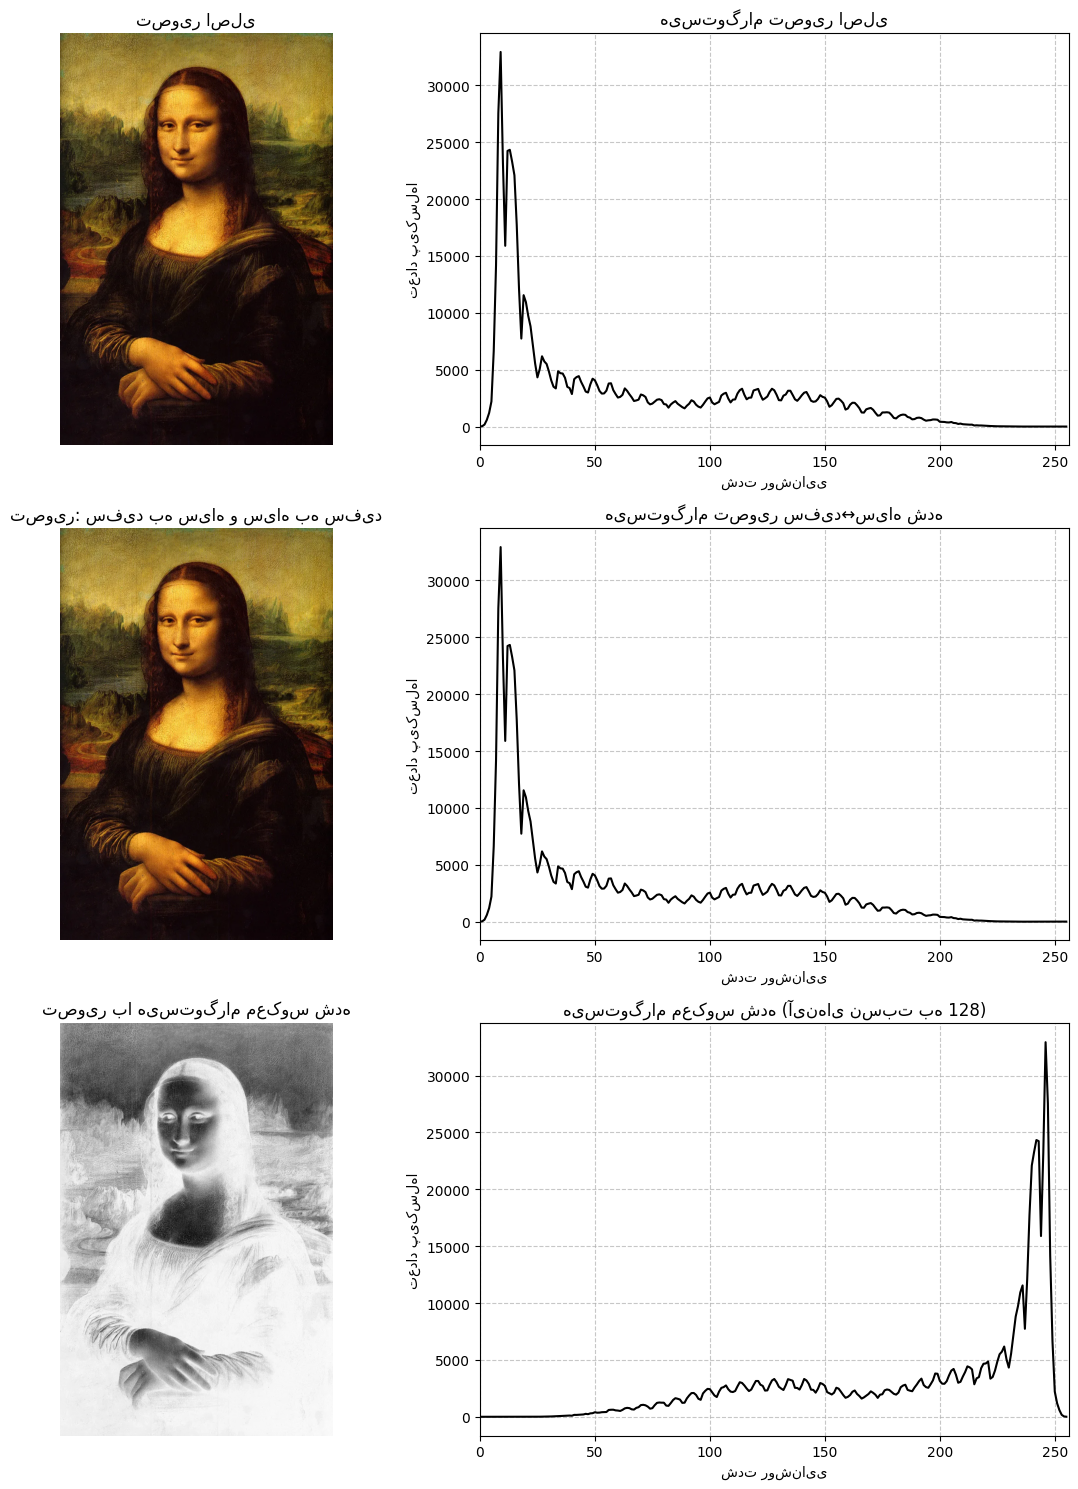

In [14]:
# Practice-4-mohammad hasan mosaferi

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1)تابع اصلی
def process_image(image_path):
    
    #  خواندن تصویر   
    img = cv2.imread(image_path)
    
    # اگر تصویر خوانده نشد، پیغام خطا بده
    if img is None:
        print("خطا: تصویر پیدا نشد!")
        return
    
    # تبدیل تصویر از BGR به RGB (چون matplotlib با RGB کار می‌کند)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # تبدیل تصویر به خاکستری برای محاسبه هیستوگرام
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # محاسبه هیستوگرام تصویر خاکستری
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
    
    # ایجاد subplot با 3 ردیف و 2 ستون
    fig, axs = plt.subplots(3, 2, figsize=(12, 15))
    
    # ========== ردیف اول ==========
    # موقعیت (1,1) - تصویر اصلی
    axs[0, 0].imshow(img_rgb)
    axs[0, 0].set_title("تصویر اصلی")
    axs[0, 0].axis('off')
    
    # موقعیت (1,2) - هیستوگرام تصویر اصلی
    axs[0, 1].plot(hist, color='black')
    axs[0, 1].set_title("هیستوگرام تصویر اصلی")
    axs[0, 1].set_xlim([0, 256])
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)
    axs[0, 1].set_xlabel("شدت روشنایی")
    axs[0, 1].set_ylabel("تعداد پیکسل‌ها")
    
    # ========== ردیف دوم: تبدیل سفید به سیاه و سیاه به سفید ==========
    # کپی از تصویر اصلی برای تغییر
    img_white_black = img_rgb.copy()
    
    # پیکسل‌های سفید خالص (255,255,255) را به سیاه (0,0,0) تبدیل کن
    # و پیکسل‌های سیاه خالص (0,0,0) را به سفید (255,255,255) تبدیل کن
    for i in range(img_white_black.shape[0]):
        for j in range(img_white_black.shape[1]):
            # اگر پیکسل سفید بود
            if (img_white_black[i, j] == [255, 255, 255]).all():
                img_white_black[i, j] = [0, 0, 0]
            # اگر پیکسل سیاه بود
            elif (img_white_black[i, j] == [0, 0, 0]).all():
                img_white_black[i, j] = [255, 255, 255]
    
    # تبدیل تصویر تغییر یافته به خاکستری برای هیستوگرام
    img_white_black_gray = cv2.cvtColor(img_white_black, cv2.COLOR_RGB2GRAY)
    hist_white_black = cv2.calcHist([img_white_black_gray], [0], None, [256], [0, 256])
    
    # موقعیت (2,1) - تصویر بعد از تبدیل سفید↔سیاه
    axs[1, 0].imshow(img_white_black)
    axs[1, 0].set_title("تصویر: سفید به سیاه و سیاه به سفید")
    axs[1, 0].axis('off')
    
    # موقعیت (2,2) - هیستوگرام تصویر تبدیل شده
    axs[1, 1].plot(hist_white_black, color='black')
    axs[1, 1].set_title("هیستوگرام تصویر سفید↔سیاه شده")
    axs[1, 1].set_xlim([0, 256])
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)
    axs[1, 1].set_xlabel("شدت روشنایی")
    axs[1, 1].set_ylabel("تعداد پیکسل‌ها")
    
    # ========== ردیف سوم: معکوس کردن سمت چپ و راست هیستوگرام ==========
    # معکوس کردن هیستوگرام نسبت به محور تقارن در شدت 128
    hist_flipped = np.zeros_like(hist)
    for i in range(256):
        # شدت i به شدت (255 - i) منتقل می‌شود
        hist_flipped[i] = hist[255 - i]
    
    img_inverted = 255 - img_gray   # معکوس ساده شدت روشنایی
    
    # موقعیت (3,1) - تصویر تغییر یافته
    axs[2, 0].imshow(img_inverted, cmap='gray')
    axs[2, 0].set_title("تصویر با هیستوگرام معکوس شده")
    axs[2, 0].axis('off')
    
    # موقعیت (3,2) - هیستوگرام معکوس شده
    # هیستوگرام تصویر معکوس شده را محاسبه می‌کنیم تا ببینیم معکوس شده
    hist_inverted = cv2.calcHist([img_inverted], [0], None, [256], [0, 256])
    
    axs[2, 1].plot(hist_inverted, color='black')
    axs[2, 1].set_title("هیستوگرام معکوس شده (آینه‌ای نسبت به 128)")
    axs[2, 1].set_xlim([0, 256])
    axs[2, 1].grid(True, linestyle='--', alpha=0.7)
    axs[2, 1].set_xlabel("شدت روشنایی")
    axs[2, 1].set_ylabel("تعداد پیکسل‌ها")
    
    # تنظیم فاصله بین subplot ها
    plt.tight_layout()
    
    # نمایش تمام نمودارها
    plt.show()

image_address =r"C:/Users/user/Desktop/mona-lisa-main.webp"  

process_image(image_address)